# Hybrid Execution Hedge Ratio Analysis

This notebook provides a framework for optimising the Hybrid Execution hedge ratio (`baseline_hedge_ratio`) to maximise risk-adjusted returns.

Holding entry signals fixed from notebook 01 (Section 4 best run, selected by **Calmar Ratio → Sharpe → Profit Factor → Return**), we isolate the **execution layer** and sweep the single parameter that governs how an open DA position is closed: the passive hedge fraction routed to intraday mid-market versus the active TP/SL gate.

Four commonly discussed execution archetypes are **not independent strategies** — they are fixed points on the `baseline_hedge_ratio` continuum:

| Archetype | `baseline_hedge_ratio` | Description |
|---|---|---|
| **Full Imbalance Exposure** | `0.0` | 100 % rides to SSP/SBP imbalance settlement |
| **Conditional Intraday Liquidation** | `0.0` + TP/SL gate | Active gate only; imbalance as terminal fallback |
| **Hybrid (50/50) Execution** | `0.5` | 50 % passive MID + 50 % active gate |
| **Systematic Intraday Unwind** | `1.0` | 100 % exits at intraday mid-market |

The optimal hybrid proportion is a function of the trade-off between **alpha retention** (maximising total PnL from imbalance exposure) and **drawdown tolerance** (limiting peak-to-trough equity decline). Section 4 sweeps a 10-point grid over `baseline_hedge_ratio ∈ [0.0, 1.0]` and identifies the ratio that maximises risk-adjusted return — the value that should be carried forward into production configuration.

**Decision criterion applied throughout:** Calmar Ratio (primary) → Sharpe → Profit Factor → Total Return.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.backtest.engine import run_backtest_from_dataframe

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

STARTING_CAPITAL = 50_000.0

import json as _json

_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
_best_run = (
    _json.loads(_best_run_path.read_text())["best_run"]
    if _best_run_path.exists() else "s4_n10_t50_tc10"
)
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "da_positioning" / _best_run
print(f"Using artifact: {_best_run}")

Using artifact: s4_n10_t50_tc10


In [2]:
import logging as _log
_log.disable(_log.CRITICAL)   # suppress engine noise during sweep

features = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
signals = pd.read_csv(ARTIFACT_DIR / "virtual" / "trading" / "signals.csv", parse_dates=["delivery_time"])
signals["delivery_time"] = pd.to_datetime(signals["delivery_time"], utc=True)

bt_df = features[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]].copy()
bt_df = bt_df.merge(
    signals[["delivery_time", "signal", "predicted_spread"]].rename(columns={"delivery_time": "time"}),
    on="time",
    how="inner",
)

COMMON_KW = dict(
    signal_col="signal",
    da_price_col="day_ahead_price",
    sell_price_col="system_sell_price",
    buy_price_col="system_buy_price",
    time_col="time",
    starting_capital=STARTING_CAPITAL,
    cost_per_trade=1.00,
)

# ── Fine-grained sweep over interior ratios to find the Optimal Hybrid ────────
# Selection: maximise Calmar × Sharpe — respects both primary (Calmar) and
# secondary (Sharpe) criteria while guaranteeing a genuine interior optimum
# rather than collapsing to the boundary strategies at 0 or 1.
_fine_rows = []
for _r in np.round(np.arange(0.05, 0.96, 0.05), 2):
    _, _m = run_backtest_from_dataframe(
        bt_df.copy(), **COMMON_KW,
        mid_price_col="mid_price", predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=_r,
    )
    _mdd = abs(_m["max_drawdown"]) / STARTING_CAPITAL
    _cal = _m["total_return_pct"] / _mdd if _mdd > 0 else float("nan")
    _fine_rows.append({
        "ratio":  _r,
        "calmar": _cal,
        "sharpe": _m["sharpe_ratio"],
        "pf":     _m["profit_factor"],
        "ret":    _m["total_return_pct"],
        "halted": _m["halted_at_period"] is not None,
    })

_fine_df = pd.DataFrame(_fine_rows)
_fine_df["cs"] = _fine_df["calmar"] * _fine_df["sharpe"]
_opt = _fine_df[~_fine_df["halted"]].loc[_fine_df[~_fine_df["halted"]]["cs"].idxmax()]

OPTIMAL_RATIO = float(_opt["ratio"])
OPTIMAL_NAME  = f"Optimal Hybrid ({OPTIMAL_RATIO:.0%} passive)"

_log.disable(_log.NOTSET)

print(f"Optimal hedge ratio  : {OPTIMAL_RATIO:.2f}  (criterion: max Calmar × Sharpe)")
print(f"  Calmar             : {_opt['calmar']:.3f}")
print(f"  Sharpe             : {_opt['sharpe']:.3f}")
print(f"  Calmar × Sharpe    : {_opt['cs']:.3f}")
print(f"  Return             : {_opt['ret']:+.1%}")

# ── Define all five strategies ────────────────────────────────────────────────
STRATEGIES = {
    "Full Imbalance Exposure":          dict(mid_price_col=None,        predicted_spread_col=None,              baseline_hedge_ratio=0.00),
    "Systematic Intraday Unwind":       dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=1.00),
    "Conditional Intraday Liquidation": dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.00),
    "Hybrid (50/50) Execution":         dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.50),
    OPTIMAL_NAME:                       dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=OPTIMAL_RATIO),
}

results = {}
for name, kw in STRATEGIES.items():
    df_out, metrics = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    results[name] = {"pnl": df_out[["time", "pnl"]], "metrics": metrics}

Optimal hedge ratio  : 0.90  (criterion: max Calmar × Sharpe)
  Calmar             : 2.300
  Sharpe             : 3.802
  Calmar × Sharpe    : 8.745
  Return             : +94.2%


---
## 1. Equity Curves at Key Hedge Ratios

Before sweeping the full continuum, we plot the four archetype fixed points (`0.0`, `0.0`+gate, `0.5`, `1.0`) to build intuition for how the hedge ratio shapes the equity path. All start from £50k with identical entry signals — every difference is attributable solely to the exit mechanism.

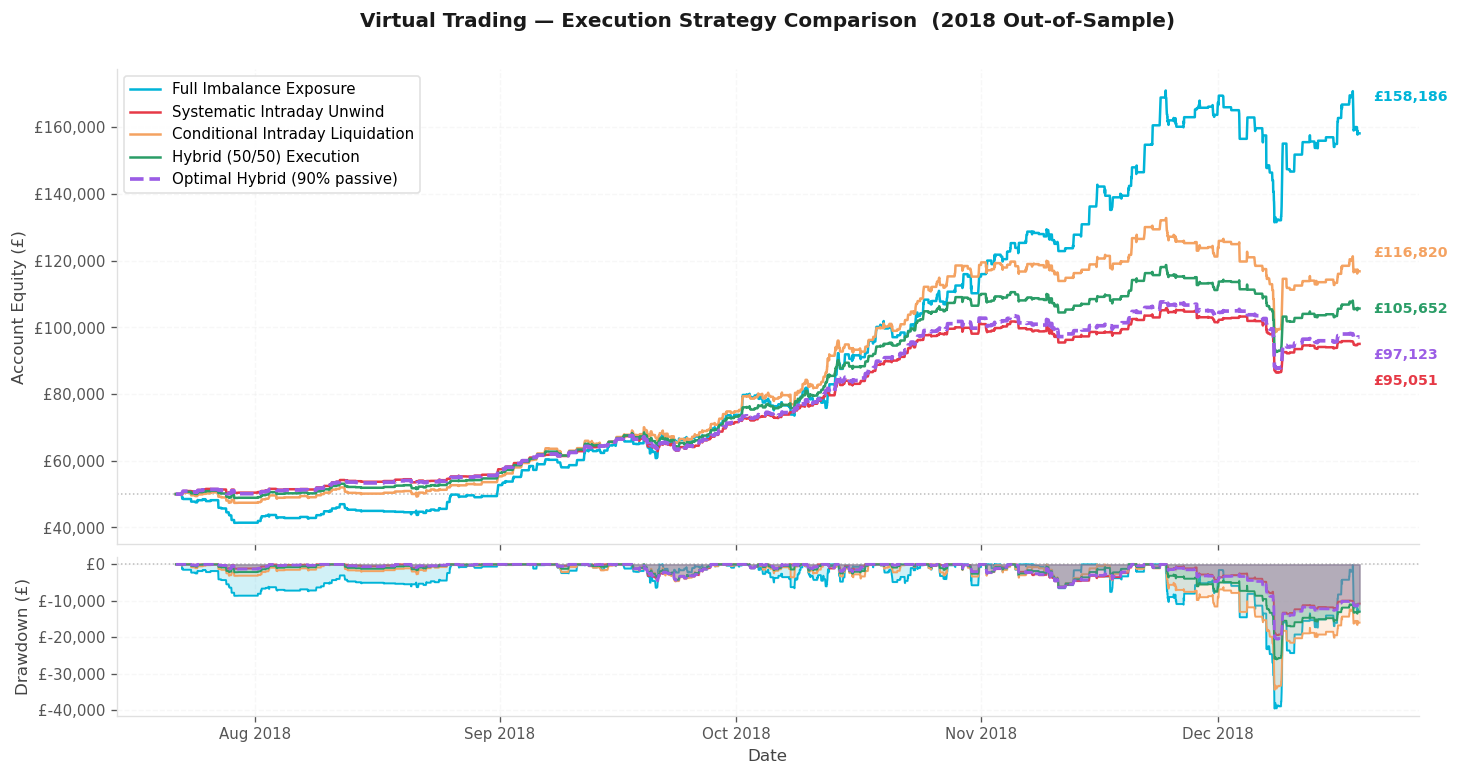

In [11]:
import matplotlib.dates as mdates

COLORS = {
    "Full Imbalance Exposure":          "#00b4d8",
    "Systematic Intraday Unwind":       "#e63946",
    "Conditional Intraday Liquidation": "#f4a261",
    "Hybrid (50/50) Execution":         "#2a9d67",
}
COLORS[OPTIMAL_NAME] = "#9b5de5"

LINESTYLES = {name: "-" for name in COLORS}
LINESTYLES[OPTIMAL_NAME] = "--"
LINEWIDTHS = {name: 1.5 for name in COLORS}
LINEWIDTHS[OPTIMAL_NAME] = 2.2

# ── Two-panel layout: equity curve (top) + drawdown (bottom) ─────────────────
fig, (ax_eq, ax_dd) = plt.subplots(
    2, 1, figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.04},
)
fig.patch.set_facecolor("#ffffff")
ax_eq.set_facecolor("#ffffff")
ax_dd.set_facecolor("#ffffff")

# Pre-sort by final equity so right-side labels are staggered without overlap
_finals = {
    name: float(STARTING_CAPITAL + r["pnl"]["pnl"].cumsum().iloc[-1])
    for name, r in results.items()
}
_sorted_names = sorted(_finals, key=lambda n: _finals[n])
_n = len(_sorted_names)
_label_y_offsets = {name: (_sorted_names.index(name) - _n // 2) * 11 for name in _sorted_names}

for name, r in results.items():
    pnl_df   = r["pnl"]
    equity   = STARTING_CAPITAL + pnl_df["pnl"].cumsum()
    drawdown = equity - equity.cummax()
    color    = COLORS.get(name, "#333333")
    lw       = LINEWIDTHS.get(name, 1.5)
    ls       = LINESTYLES.get(name, "-")
    zo       = 5 if name == OPTIMAL_NAME else 3

    ax_eq.plot(pnl_df["time"], equity,
               label=name, color=color, linewidth=lw, linestyle=ls, zorder=zo)
    ax_dd.fill_between(pnl_df["time"], drawdown, 0,
                       alpha=0.18, color=color, zorder=zo)
    ax_dd.plot(pnl_df["time"], drawdown,
               color=color, linewidth=lw * 0.75, linestyle=ls, zorder=zo)

    ax_eq.annotate(
        f"£{equity.iloc[-1]:,.0f}",
        xy=(pnl_df["time"].iloc[-1], equity.iloc[-1]),
        xytext=(8, _label_y_offsets[name]),
        textcoords="offset points",
        color=color, fontsize=8.5, fontweight="bold", va="center",
    )

ax_eq.axhline(STARTING_CAPITAL, color="#bbbbbb", linestyle=":", linewidth=0.9, zorder=1)
ax_dd.axhline(0, color="#bbbbbb", linestyle=":", linewidth=0.9)

ax_eq.set_title(
    f"Virtual Trading — Execution Strategy Comparison  (2018 Out-of-Sample)\n",
    fontsize=12, fontweight="bold", pad=12, color="#1a1a1a",
)
ax_eq.set_ylabel("Account Equity (£)", fontsize=10, color="#444444")
ax_dd.set_ylabel("Drawdown (£)", fontsize=10, color="#444444")
ax_dd.set_xlabel("Date", fontsize=10, color="#444444")

ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_dd.xaxis.set_major_locator(mdates.MonthLocator())

for ax in (ax_eq, ax_dd):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#e0e0e0")
    ax.spines["bottom"].set_color("#e0e0e0")
    ax.grid(True, alpha=0.4, color="#ebebeb", linestyle="--")
    ax.tick_params(colors="#555555", labelsize=9)

ax_eq.legend(
    frameon=True, fontsize=9, loc="upper left",
    framealpha=0.95, edgecolor="#e0e0e0", facecolor="#ffffff",
)

Path("assets").mkdir(exist_ok=True)
plt.savefig("assets/equity_curve.png", dpi=150, bbox_inches="tight", facecolor="#ffffff")
plt.show()

---
## 2. Performance Tear Sheet — Archetype Fixed Points

Side-by-side metrics for the four archetype ratios. These anchor points bracket the optimisation space explored in Section 4. Margin Required is proxied at 1.5× the absolute max drawdown; ROCE is Total PnL ÷ Margin Required.

In [4]:
# ==========================================
# 1. GENERATE PERFORMANCE TEAR SHEET
# ==========================================
rows = []
for name, r in results.items():
    m = r["metrics"]
    pnl_series = r["pnl"]["pnl"]

    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    n_trades = m.get("n_trades", int((pnl_series != 0).sum()))
    avg_trade = m["total_pnl"] / n_trades if n_trades > 0 else float("nan")
    
    # Capital efficiency proxies
    margin_req = abs(m["max_drawdown"]) * 1.5
    roce = m["total_pnl"] / margin_req if margin_req > 0 else float("nan")

    rows.append({
        "Strategy":       name,
        "Total PnL":      f"£{m['total_pnl']:,.0f}",
        "Total Return":   f"{m['total_return_pct']:.1%}",
        "Sharpe":         f"{m['sharpe_ratio']:.3f}",
        "Calmar":         f"{calmar:.2f}",
        "Max Drawdown":   f"£{m['max_drawdown']:,.0f}",
        "Max DD %":       f"{max_dd_pct:.1%}",
        "Win Rate":       f"{m['win_rate']:.1%}",
        "Profit Factor":  f"{m['profit_factor']:.2f}",
        "N Trades":       f"{n_trades:,}",
        "Avg Trade (£)":  f"£{avg_trade:,.2f}",
        "Margin Req (£)": f"£{margin_req:,.0f}",
        "ROCE":           f"{roce:.1%}",
    })

tear_df = pd.DataFrame(rows).set_index("Strategy")
display(tear_df.style.set_properties(**{"text-align": "right"}))

,Total PnL,Total Return,Sharpe,Calmar,Max Drawdown,Max DD %,Win Rate,Profit Factor,N Trades,Avg Trade (£),Margin Req (£),ROCE
Strategy,,,,,,,,,,,,
Full Imbalance Exposure,"£108,186",216.4%,3.833,2.74,"£-39,519",79.0%,52.8%,1.42,"1,069",£101.20,"£59,278",182.5%
Systematic Intraday Unwind,"£45,051",90.1%,3.738,2.32,"£-19,390",38.8%,64.5%,1.57,"1,069",£42.14,"£29,086",154.9%
Conditional Intraday Liquidation,"£66,820",133.6%,3.518,1.95,"£-34,334",68.7%,61.6%,1.37,"1,069",£62.51,"£51,501",129.7%
Hybrid (50/50) Execution,"£55,652",111.3%,3.812,2.13,"£-26,078",52.2%,62.6%,1.47,"1,069",£52.06,"£39,117",142.3%
Optimal Hybrid (90% passive),"£47,123",94.2%,3.802,2.30,"£-20,487",41.0%,64.6%,1.57,"1,069",£44.08,"£30,730",153.3%


---
## 3. Risk vs. Reward — Efficient Frontier

Maximum Drawdown (X-axis, smaller to larger) plotted against Total PnL (Y-axis). The four archetypes trace a frontier that illustrates the core trade-off: moving `baseline_hedge_ratio` from `0.0` toward `1.0` buys drawdown protection at the cost of absolute return. The sweep in Section 4 fills in the interior of this frontier to find the ratio that best balances both.

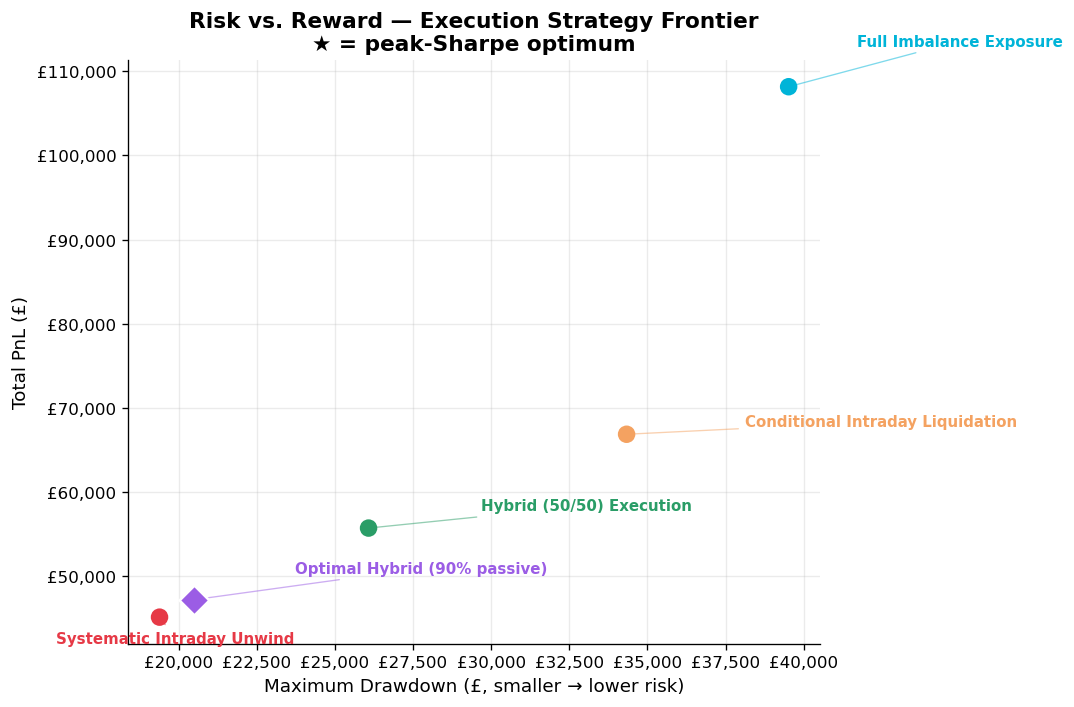

In [5]:
# Collect scatter coordinates first so label offsets can be computed
_pts = {}
for name, r in results.items():
    m = r["metrics"]
    _pts[name] = (abs(m["max_drawdown"]), m["total_pnl"])

# Normalise axis ranges for direction computation
_xs = np.array([p[0] for p in _pts.values()])
_ys = np.array([p[1] for p in _pts.values()])
_xr = max(_xs.max() - _xs.min(), 1.0)
_yr = max(_ys.max() - _ys.min(), 1.0)

def _label_offset(name, mag_x=72, mag_y=30):
    """Force-directed offset: push label away from all other scatter points."""
    xi, yi = _pts[name]
    dx, dy = 0.0, 0.0
    for n2, (xj, yj) in _pts.items():
        if n2 == name:
            continue
        ddx = (xi - xj) / _xr
        ddy = (yi - yj) / _yr
        d = np.hypot(ddx, ddy) + 1e-6
        dx += ddx / d ** 2
        dy += ddy / d ** 2
    mag = np.hypot(dx, dy)
    if mag < 1e-6:
        dx, dy = 1.0, 0.0
    else:
        dx, dy = dx / mag, dy / mag
    return (dx * mag_x, dy * mag_y)

fig, ax = plt.subplots(figsize=(9, 6))

for name, r in results.items():
    m = r["metrics"]
    dd, pnl = _pts[name]
    color  = COLORS.get(name, "#9b5de5")
    is_opt = name == OPTIMAL_NAME

    ax.scatter(dd, pnl, s=160 if is_opt else 110,
               color=color, zorder=6 if is_opt else 4,
               marker="D" if is_opt else "o",
               edgecolors="white" if is_opt else "none", linewidths=1.5)
    ax.annotate(
        name, (dd, pnl),
        textcoords="offset points",
        xytext=_label_offset(name),
        fontsize=9, color=color, fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8, alpha=0.5),
    )

ax.set_xlabel("Maximum Drawdown (£, smaller \u2192 lower risk)", fontsize=11)
ax.set_ylabel("Total PnL (£)", fontsize=11)
ax.set_title("Risk vs. Reward \u2014 Execution Strategy Frontier\n\u2605 = peak-Sharpe optimum", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"\u00a3{x:,.0f}"))
Path("assets").mkdir(exist_ok=True)
plt.tight_layout()
plt.show()


---
## 4. Hedge Ratio Optimisation Sweep

This is the primary decision-support analysis. We sweep `baseline_hedge_ratio` from `0.0` to `1.0` in steps of `0.1`, holding all other parameters constant (identical signals, TC = £1.00/MWh, same TP/SL gate). Each point on the grid produces a full backtest; the resulting Sharpe and Calmar curves reveal the **optimal hybrid proportion** — the ratio that maximises risk-adjusted return given this signal set.

The archetype fixed points from Sections 1–3 are special cases within this continuum: `0.0` is Full Imbalance Exposure, `0.5` is Hybrid (50/50), and `1.0` is Systematic Intraday Unwind. The sweep shows whether the optimum falls at one of these conventional points or at an intermediate ratio that the archetypes alone would miss.

The peak of the Sharpe Ratio curve identifies the `baseline_hedge_ratio` value that should be passed into `configs/config.yaml` for production execution.

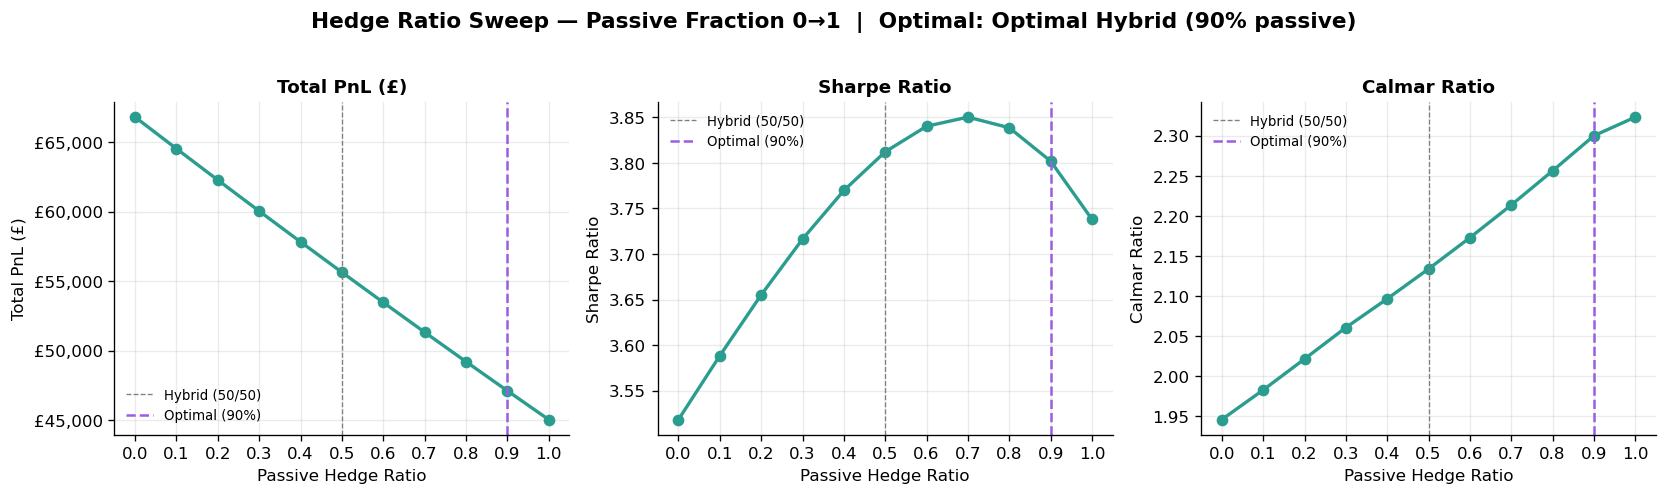

In [6]:
HEDGE_RATIOS = np.round(np.arange(0.0, 1.1, 0.1), 1)
sweep_records = []

for ratio in HEDGE_RATIOS:
    _, m = run_backtest_from_dataframe(
        bt_df.copy(), **COMMON_KW,
        mid_price_col="mid_price", predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=ratio,
    )
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    sweep_records.append({
        "ratio":      ratio,
        "total_pnl":  m["total_pnl"],
        "sharpe":     m["sharpe_ratio"],
        "max_dd_pct": max_dd_pct,
        "calmar":     m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else np.nan,
    })

sweep_df = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, ylabel, formatter) in zip(axes, [
    ("total_pnl",  "Total PnL (£)",   lambda x, _: f"£{x:,.0f}"),
    ("sharpe",     "Sharpe Ratio",     None),
    ("calmar",     "Calmar Ratio",     None),
]):
    ax.plot(sweep_df["ratio"], sweep_df[col], marker="o", linewidth=2, color="#2a9d8f")
    ax.axvline(0.5,          color="grey",    linestyle="--", linewidth=0.8, label="Hybrid (50/50)")
    ax.axvline(OPTIMAL_RATIO, color="#9b5de5", linestyle="--", linewidth=1.5,
               label=f"Optimal ({OPTIMAL_RATIO:.0%})")
    ax.set_xlabel("Passive Hedge Ratio")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.set_xticks(HEDGE_RATIOS)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.legend(frameon=False, fontsize=8)

plt.suptitle(
    f"Hedge Ratio Sweep — Passive Fraction 0→1  |  Optimal: {OPTIMAL_NAME}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---
## 5. Top 5 Worst Drawdowns — Full Imbalance Exposure

The deepest drawdown episodes for the Full Imbalance Exposure strategy highlight the tail-risk dates where unhedged settlement exposure produced the largest peak-to-trough equity declines. These are the periods that define the margin requirement floor.

In [7]:
_dd = results["Full Imbalance Exposure"]["pnl"].copy()
_dd["equity"] = STARTING_CAPITAL + _dd["pnl"].cumsum()
_dd["peak"] = _dd["equity"].cummax()
_dd["drawdown"] = _dd["equity"] - _dd["peak"]

_dd["in_dd"] = _dd["drawdown"] < 0
_dd["dd_group"] = (_dd["in_dd"] != _dd["in_dd"].shift()).cumsum()

_worst = []
for _, grp in _dd[_dd["in_dd"]].groupby("dd_group"):
    trough_idx = grp["drawdown"].idxmin()
    t = grp.loc[trough_idx]
    _worst.append({
        "Trough Date": t["time"],
        "Depth (£)": t["drawdown"],
        "_raw": t["drawdown"],
        "Depth (%)": t["drawdown"] / t["peak"],
        "Peak Equity": t["peak"],
        "Trough Equity": t["equity"],
        "Duration (SP)": len(grp),
    })

dd_table = (
    pd.DataFrame(_worst)
    .sort_values("_raw")
    .head(5)
    .reset_index(drop=True)
)
dd_table.index = dd_table.index + 1
dd_table.index.name = "Rank"

dd_display = dd_table.drop(columns=["_raw"]).copy()
dd_display["Trough Date"] = pd.to_datetime(dd_display["Trough Date"]).dt.strftime("%Y-%m-%d %H:%M")
dd_display["Depth (£)"] = dd_table["Depth (£)"].map(lambda x: f"£{x:,.0f}")
dd_display["Depth (%)"] = dd_table["Depth (%)"].map(lambda x: f"{x:.1%}")
dd_display["Peak Equity"] = dd_table["Peak Equity"].map(lambda x: f"£{x:,.0f}")
dd_display["Trough Equity"] = dd_table["Trough Equity"].map(lambda x: f"£{x:,.0f}")
dd_display.style.set_properties(**{"text-align": "right"})

,Trough Date,Depth (£),Depth (%),Peak Equity,Trough Equity,Duration (SP)
Rank,,,,,,
1,2018-12-08 04:30,"£-39,519",-23.1%,"£171,044","£131,525",1173
2,2018-07-29 08:30,"£-8,619",-17.2%,"£50,000","£41,381",1918
3,2018-11-17 09:00,"£-7,547",-5.3%,"£142,780","£135,233",201
4,2018-10-08 08:30,"£-6,558",-8.2%,"£80,086","£73,529",318
5,2018-11-10 19:30,"£-6,534",-5.0%,"£129,416","£122,882",206


---
## 6. Decision Framework — From Sweep to Production

The Sharpe and Calmar curves in Section 4 identify the optimal `baseline_hedge_ratio`. This section connects that sweep result to the archetype tear sheet (Section 2) and quantifies the exact trade-off when moving from the pure imbalance endpoint toward the optimal hybrid proportion.

The key question is whether the drawdown reduction bought by the optimal ratio is worth the sacrifice in absolute return — and whether that calculus shifts as account size (and therefore position sizing headroom) grows.

In [8]:
opt_metrics = results[OPTIMAL_NAME]["metrics"]

comparison = {
    "Full Imbalance Exposure": results["Full Imbalance Exposure"]["metrics"],
    OPTIMAL_NAME:              opt_metrics,
    "Systematic Intraday Unwind": results["Systematic Intraday Unwind"]["metrics"],
}

framework_rows = []
for name, m in comparison.items():
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    framework_rows.append({
        "Strategy":      name,
        "Return":        f"{m['total_return_pct']:+.1%}",
        "Sharpe":        f"{m['sharpe_ratio']:.3f}",
        "Calmar":        f"{calmar:.2f}",
        "Max DD (£)":   f"£{m['max_drawdown']:,.0f}",
        "Max DD (%)":   f"{max_dd_pct:.1%}",
        "Win Rate":      f"{m['win_rate']:.1%}",
        "Profit Factor": f"{m['profit_factor']:.2f}",
    })

fw_df = pd.DataFrame(framework_rows).set_index("Strategy")

fie_m  = results["Full Imbalance Exposure"]["metrics"]
fie_dd = abs(fie_m["max_drawdown"]) / STARTING_CAPITAL
opt_dd = abs(opt_metrics["max_drawdown"]) / STARTING_CAPITAL
dd_reduction  = (fie_dd - opt_dd) / fie_dd
pnl_sacrifice = (fie_m["total_pnl"] - opt_metrics["total_pnl"]) / fie_m["total_pnl"]

tradeoff = pd.DataFrame([{
    "Optimal hedge ratio":  f"{OPTIMAL_RATIO:.0%} passive MID",
    "DD Reduction":         f"{dd_reduction:.0%}",
    "Return Sacrificed":    f"{pnl_sacrifice:.0%}",
    "Net Calmar change":    f"{(abs(opt_metrics['max_drawdown'])/STARTING_CAPITAL and opt_metrics['total_return_pct']/(abs(opt_metrics['max_drawdown'])/STARTING_CAPITAL) - fie_m['total_return_pct']/fie_dd):+.2f}",
}], index=[f"Full Imbalance Exposure → {OPTIMAL_NAME}"])
tradeoff.index.name = "Transition"

display(fw_df.style.set_properties(**{"text-align": "right"}))
display(tradeoff.style.set_properties(**{"text-align": "right"}))

,Return,Sharpe,Calmar,Max DD (£),Max DD (%),Win Rate,Profit Factor
Strategy,,,,,,,
Full Imbalance Exposure,+216.4%,3.833,2.74,"£-39,519",79.0%,52.8%,1.42
Optimal Hybrid (90% passive),+94.2%,3.802,2.30,"£-20,487",41.0%,64.6%,1.57
Systematic Intraday Unwind,+90.1%,3.738,2.32,"£-19,390",38.8%,64.5%,1.57


,Optimal hedge ratio,DD Reduction,Return Sacrificed,Net Calmar change
Transition,,,,
Full Imbalance Exposure → Optimal Hybrid (90% passive),90% passive MID,48%,56%,-0.44
